In [1]:
import numpy as np
import pandas as pd

In [2]:
data = {
    'City': ['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Delhi', 'Mumbai', 'Chennai', 'Bangalore'],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Female', 'Male', 'Male', 'Female'],
    'Education': ['Bachelors', 'Masters', 'PhD', 'Bachelors', 'Masters', 'PhD', 'Bachelors', 'Masters'],
    'Age': [25, 30, 35, 28, 32, 40, 27, 29],
    'Salary': [50000, 60000, 80000, 52000, 62000, 90000, 48000, 58000]
}

In [3]:
df = pd.DataFrame(data)
df.head()

,City,Gender,Education,Age,Salary
0,Delhi,Male,Bachelors,25,50000
1,Mumbai,Female,Masters,30,60000
2,Bangalore,Male,PhD,35,80000
3,Chennai,Female,Bachelors,28,52000
4,Delhi,Female,Masters,32,62000


In [4]:
X = df.iloc[:,0:4]
y = df.iloc[:,-1]

In [9]:
df[["Education"]].value_counts()

Education
Bachelors    3
Masters      3
PhD          2
Name: count, dtype: int64

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

In [16]:
ct = ColumnTransformer(
    transformers=[
        ("ct1", OrdinalEncoder(categories=[["Bachelors", "Masters", "PhD"]]), ["Education"]),
        ("ct2", OneHotEncoder(drop="first", sparse_output=False), ["Gender", "City"])
    ],
    remainder='passthrough'
)


In [18]:
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ct1', ...), ('ct2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [20]:
X = np.array(ct.fit_transform(X))

In [21]:
X

array([[ 0.,  1.,  0.,  1.,  0., 25.],
       [ 1.,  0.,  0.,  0.,  1., 30.],
       [ 2.,  1.,  0.,  0.,  0., 35.],
       [ 0.,  0.,  1.,  0.,  0., 28.],
       [ 1.,  0.,  0.,  1.,  0., 32.],
       [ 2.,  1.,  0.,  0.,  1., 40.],
       [ 0.,  1.,  1.,  0.,  0., 27.],
       [ 1.,  0.,  0.,  0.,  0., 29.]])

In [22]:
y

0    50000
1    60000
2    80000
3    52000
4    62000
5    90000
6    48000
7    58000
Name: Salary, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [59]:
X_train

array([[ 1.78885438,  1.        , -0.70710678, -0.4472136 , -0.4472136 ,
         1.92980256],
       [ 0.4472136 , -1.        , -0.70710678, -0.4472136 ,  2.23606798,
         0.32163376],
       [ 0.4472136 , -1.        , -0.70710678, -0.4472136 , -0.4472136 ,
         0.        ],
       [-0.89442719,  1.        , -0.70710678,  2.23606798, -0.4472136 ,
        -1.28653504],
       [-0.89442719, -1.        ,  1.41421356, -0.4472136 , -0.4472136 ,
        -0.32163376],
       [-0.89442719,  1.        ,  1.41421356, -0.4472136 , -0.4472136 ,
        -0.64326752]])

In [30]:
len(X_test)

2

In [36]:
from sklearn.preprocessing import StandardScaler

st = StandardScaler()
X_train = st.fit_transform(X_train)
X_test = st.fit_transform(X_test)

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
lr = LinearRegression()

In [39]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = lr.predict(X_test)

In [42]:
import matplotlib.pyplot as plt

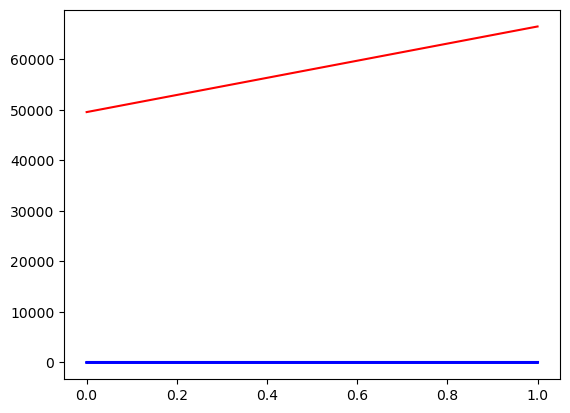

In [45]:
plt.plot(y_pred, color = "r")
plt.plot(X_test,color = "b")
plt.show()

In [52]:
data = [[2.,  1.,  0.,  0.,  0., 35]]

In [53]:
pd.DataFrame(data)

,0,1,2,3,4,5
0,2.0,1.0,0.0,0.0,0.0,35


In [54]:
data

[[2.0, 1.0, 0.0, 0.0, 0.0, 35]]

In [55]:
st = st.fit_transform(data)

In [56]:
single = lr.predict(st)

In [57]:
single

array([58000.])